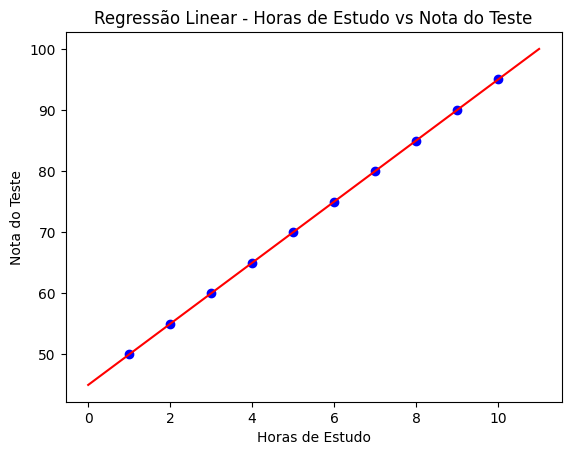

In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Dados
horas_estudo = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
notas_teste = np.array([50, 55, 60, 65, 70, 75, 80, 85, 90, 95])

# Criando o modelo de regressão linear
modelo = LinearRegression()
modelo.fit(horas_estudo, notas_teste)

# Previsão
horas_estudo_pred = np.array([0, 11]).reshape(-1, 1)
notas_pred = modelo.predict(horas_estudo_pred)

# Plotando os resultados
plt.scatter(horas_estudo, notas_teste, color='blue')
plt.plot(horas_estudo_pred, notas_pred, color='red')
plt.title('Regressão Linear - Horas de Estudo vs Nota do Teste')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota do Teste')
plt.show()

# MODELO DE REGRESSÃO LINEAR PELA EQUAÇÃO NORMAL

**Instituição:** Universidade de Brasília

**Disciplina:** FGA0083 - Aprendizado de Máquina

**Professor:** Dr. Sergio Antônio Andrade de Freitas

---

## 1. INTRODUÇÃO

Este exercício demonstra a implementação de um modelo de Regressão Linear Simples, calculando os seus coeficientes diretamente por meio da **Equação Normal**. O objetivo é ilustrar o processo de modelagem em um conjunto de dados sintético que simula a relação entre o tempo de estudo e a nota de um aluno.

---

## 2. METODOLOGIA

O processo envolve a geração de dados, o cálculo analítico dos parâmetros do modelo e a visualização do ajuste.

### 2.1. Importação das bibliotecas e geração de dados

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Passo 1: Gerar Dados Sintéticos
np.random.seed(42)  # Semente para reprodutibilidade
tempo_de_estudo = 10 * np.random.rand(100, 1)  # Tempo de estudo entre 0 e 10 horas
nota_base = 5  # Nota base assumida sem estudo
nota_por_hora = 0.5  # Ganho de nota por hora de estudo

# A nota final inclui um ruído aleatório para simular variabilidade real
notas = nota_base + nota_por_hora * tempo_de_estudo + np.random.randn(100, 1)

print("Dados sintéticos gerados.")

Dados sintéticos gerados.


### 2.2. Passo 2: Cálculo dos coeficientes pela equação normal

Os coeficientes do modelo (parâmetros $ \theta $) são calculados diretamente pela Equação Normal: $ \hat{\theta} = (X^T X)^{-1} X^T y $. Para isso, adiciona-se uma coluna de 1s à matriz de *features* `X` para o termo de interceptação ($ \theta_0 $).

In [3]:
# Adiciona o termo de interceptação x0 = 1 a cada instância
X_b = np.c_[np.ones((100, 1)), tempo_de_estudo]

# Calcula os coeficientes ótimos usando a Equação Normal
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(notas)

print("Coeficientes (theta) calculados:")
print(theta_best)

Coeficientes (theta) calculados:
[[5.21509616]
 [0.45402268]]


## 3. RESULTADOS E ANÁLISE

Com os coeficientes calculados, o ajuste do modelo é visualizado e utilizado para prever novos valores.

### 3.1. Passo 3: Visualização do ajuste linear

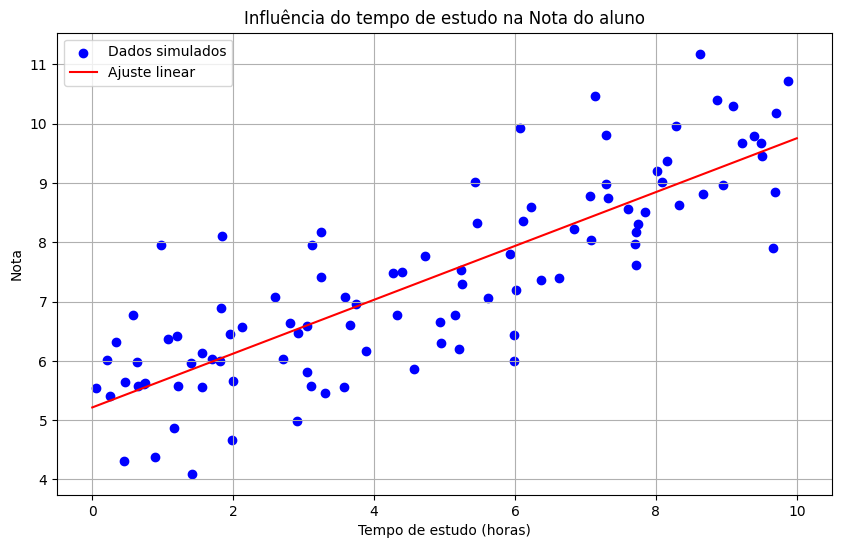

In [6]:
# Passo 3: Visualização dos Dados e do Ajuste Linear
plt.figure(figsize=(10, 6))
plt.scatter(tempo_de_estudo, notas, color='blue', label='Dados simulados')

# Define a linha de regressão com base nos coeficientes calculados
line_x = np.array([[0], [10]])
line_x_b = np.c_[np.ones((2, 1)), line_x]
line_y = line_x_b.dot(theta_best)

plt.plot(line_x, line_y, color='red', label='Ajuste linear')
plt.xlabel('Tempo de estudo (horas)')
plt.ylabel('Nota')
plt.title('Influência do tempo de estudo na Nota do aluno')
plt.legend()
plt.grid(True)
plt.show()

### 3.2. Passo 4: Predição de notas com o modelo

O modelo é usado para prever as notas de dois alunos: um com 0 horas de estudo e outro com 10 horas.

In [5]:
# Passo 4: Predição de Notas com o Modelo
X_new = np.array([[0], [10]])  # Aluno que não estudou e aluno que estudou 10 horas
X_new_b = np.c_[np.ones((2, 1)), X_new]
notas_previstas = X_new_b.dot(theta_best)

print("Notas previstas para [0, 10] horas de estudo:")
print(notas_previstas)

Notas previstas para [0, 10] horas de estudo:
[[5.21509616]
 [9.75532293]]


## 4. CONCLUSÃO

A análise de regressão linear foi executada, modelando a relação entre o tempo de estudo e a nota final. O modelo matemático foi ajustado, e seus coeficientes ($ \theta $) foram calculados e impressos na **Célula 6**. A **Célula 8** gerou uma visualização gráfica da linha de regressão, enquanto a **Célula 10** apresentou predições para novos dados.

Com base nos resultados numéricos e visuais, o leitor é convidado a realizar sua própria interpretação. Analise os valores e o gráfico para responder a questões como:

* Qual o significado prático do primeiro valor no vetor `theta_best` (o intercepto)?
* O que o segundo valor em `theta_best` (a inclinação) indica sobre o impacto de cada hora a mais de estudo?
* As notas previstas na última célula são consistentes com o que o gráfico sugere?